In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GridSearchCV, StratifiedGroupKFold, cross_val_score
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import optuna
import shap

/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filePath = "/Users/pritibhunia/repos/medium-voltage-cable/Real Data/TD_complete_updated_20241219.csv"
data = pd.read_csv(filePath, delimiter=';')
data.dropna(inplace=True)
print(data.head())


   cable_id  meas_id cable_type_group        date      time  step_id  line_nr  \
0         2      132     Papier-Masse  2021-04-29  09:42:37     2099        1   
1         2      132     Papier-Masse  2021-04-29  09:42:37     2100        1   
2         2      132     Papier-Masse  2021-04-29  09:42:37     2101        1   
3         2      132     Papier-Masse  2021-04-29  09:42:37     2102        1   
4         2      132     Papier-Masse  2021-04-29  09:42:37     2103        2   

   voltage_step_factor    MTD    STD  ...  Skirt Type MTD@1.0   DTD  \
0                  0.5  3.950  0.050  ...  Increasing   4.583  2.65   
1                  1.0  4.583  0.037  ...  Increasing   4.583  2.65   
2                  1.5  6.600  0.082  ...  Increasing   4.583  2.65   
3                  2.0  9.750  0.050  ...  Increasing   4.583  2.65   
4                  0.5  4.333  0.047  ...  Increasing   5.117  2.55   

   Line Deviation category_mtd category_dtd category_std  \
0            2.21         

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2763 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   cable_id                      2763 non-null   int64  
 1   meas_id                       2763 non-null   int64  
 2   cable_type_group              2763 non-null   object 
 3   date                          2763 non-null   object 
 4   time                          2763 non-null   object 
 5   step_id                       2763 non-null   int64  
 6   line_nr                       2763 non-null   int64  
 7   voltage_step_factor           2763 non-null   float64
 8   MTD                           2763 non-null   float64
 9   STD                           2763 non-null   float64
 10  Skirt                         2763 non-null   float64
 11  Skirt Type                    2763 non-null   object 
 12  MTD@1.0                       2763 non-null   float64
 13  DTD     

In [4]:
data

,cable_id,meas_id,cable_type_group,date,time,step_id,line_nr,voltage_step_factor,MTD,STD,...,Skirt Type,MTD@1.0,DTD,Line Deviation,category_mtd,category_dtd,category_std,category_line_deviation,additional_skirt_information,category_final
0,2,132,Papier-Masse,2021-04-29,09:42:37,2099,1,0.5,3.950,0.050,...,Increasing,4.583,2.650,2.21,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
1,2,132,Papier-Masse,2021-04-29,09:42:37,2100,1,1.0,4.583,0.037,...,Increasing,4.583,2.650,2.4,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
2,2,132,Papier-Masse,2021-04-29,09:42:37,2101,1,1.5,6.600,0.082,...,Increasing,4.583,2.650,2.13,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
3,2,132,Papier-Masse,2021-04-29,09:42:37,2102,1,2.0,9.750,0.050,...,Increasing,4.583,2.650,2.02,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
4,2,132,Papier-Masse,2021-04-29,09:42:37,2103,2,0.5,4.333,0.047,...,Increasing,5.117,2.550,2.01,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,175,212,Mischkabel,2022-11-16,12:59:05,3862,3,0.8,0.021,0.029,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2778,175,212,Mischkabel,2022-11-16,12:59:05,3863,3,1.0,0.164,0.196,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2779,175,212,Mischkabel,2022-11-16,12:59:05,3864,3,1.3,0.083,0.108,...,Decreasing,0.164,0.148,2.52,1,1,1,3,Ansatzweise Feuchtigkeit,3
2780,175,212,Mischkabel,2022-11-16,12:59:05,3865,3,1.5,0.154,0.130,...,Increasing,0.164,0.148,5.31,1,1,1,4,Leichte water tree Alterung,4


In [5]:
target_column = 'category_final'

In [6]:
data['Line Deviation'] = pd.to_numeric(data['Line Deviation'], errors='coerce')
data['Line Deviation'].fillna(data['Line Deviation'].median(), inplace=True)

/var/folders/l4/hjg6t7yd399dvgb3tbygj7hr0000gn/T/ipykernel_42272/3980992609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Line Deviation'].fillna(data['Line Deviation'].median(), inplace=True)


In [7]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'date' column:
['2021-04-29' '2021-04-27' '2021-04-28' '2023-04-20' '2019-10-10'
 '2019-10-11' '2022-09-13' '2021-09-28' '2021-10-21' '2021-10-14'
 '2021-10-05' '2021-10-04' '2021-11-01' '2021-09-23' '2021-10-06'
 '2021-09-30' '2021-11-22' '2021-09-13' '2021-09-20' '2021-12-08'
 '2021-10-07' '2021-10-12' '2021-10-19' '2021-10-18' '2021-10-20'
 '2021-10-13' '2021-10-11' '2021-09-21' '2021-09-08' '2021-09-16'
 '2021-06-10' '2021-09-14' '2021-11-25' '2021-09-07' '2021-09-09'
 '2021-12-07' '2022-09-10' '2022-09-12' '2021-09-27' '2021-09-06'
 '2022-11-14' '2022-11-17' '2023-04-18' '2023-04-19' '2022-11-15'
 '2022-12-14' '2022-11-16' '2022-12-12' '2022-12-13' '2022-12-15'
 '2023-04-17' '2022-11-18']
------------------------------
Distinct values in 'time' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [8]:
data.isnull().sum()

cable_id                        0
meas_id                         0
cable_type_group                0
date                            0
time                            0
step_id                         0
line_nr                         0
voltage_step_factor             0
MTD                             0
STD                             0
Skirt                           0
Skirt Type                      0
MTD@1.0                         0
DTD                             0
Line Deviation                  0
category_mtd                    0
category_dtd                    0
category_std                    0
category_line_deviation         0
additional_skirt_information    0
category_final                  0
dtype: int64

In [9]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [10]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
[1 0 2]
------------------------------
Distinct values in 'date' column:
[ 4  2  3 51  0  1 38 17 30 26 20 19 31 15 21 18 32 10 13 35 22 24 28 27
 29 25 23 14  8 12  5 11 33  7  9 34 36 37 16  6 39 42 49 50 40 46 41 44
 45 47 48 43]
------------------------------
Distinct values in 'time' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34  80  53   5  41   2
  95 109]
------------------------------
Distinct values in 'Skirt Type'

                              cable_id   meas_id  cable_type_group      date  \
cable_id                      1.000000  0.717868         -0.244753  0.749244   
meas_id                       0.717868  1.000000         -0.396163  0.609278   
cable_type_group             -0.244753 -0.396163          1.000000 -0.374867   
date                          0.749244  0.609278         -0.374867  1.000000   
time                         -0.074072  0.039957         -0.129317 -0.075692   
step_id                       0.731206  0.964314         -0.443948  0.613406   
line_nr                       0.001822  0.004238         -0.004381  0.009506   
voltage_step_factor          -0.036028  0.004779         -0.007876 -0.031495   
MTD                           0.033615  0.028320          0.016688  0.024852   
STD                           0.018729  0.019770          0.012043  0.014563   
Skirt                        -0.018053 -0.019190         -0.012000 -0.013974   
Skirt Type                   -0.045625 -

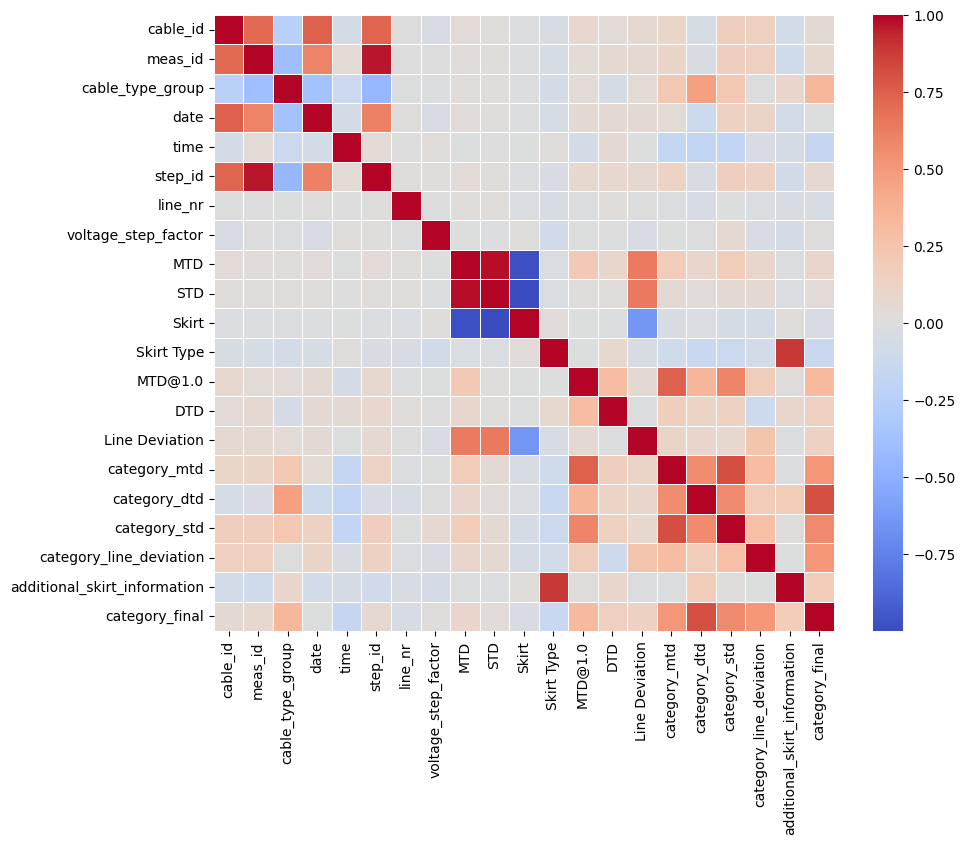

In [11]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

                               meas_id  cable_type_group   line_nr  \
meas_id                       1.000000         -0.396163  0.004238   
cable_type_group             -0.396163          1.000000 -0.004381   
line_nr                       0.004238         -0.004381  1.000000   
voltage_step_factor           0.004779         -0.007876  0.000217   
MTD                           0.028320          0.016688  0.021869   
STD                           0.019770          0.012043  0.023389   
Skirt                        -0.019190         -0.012000 -0.023515   
Skirt Type                   -0.054635         -0.075638 -0.043344   
MTD@1.0                       0.046067          0.036121 -0.009925   
DTD                           0.065794         -0.058648  0.019319   
Line Deviation                0.067549          0.039455  0.006840   
additional_skirt_information -0.095162          0.099717 -0.046615   
category_final                0.074819          0.343357 -0.041576   

                   

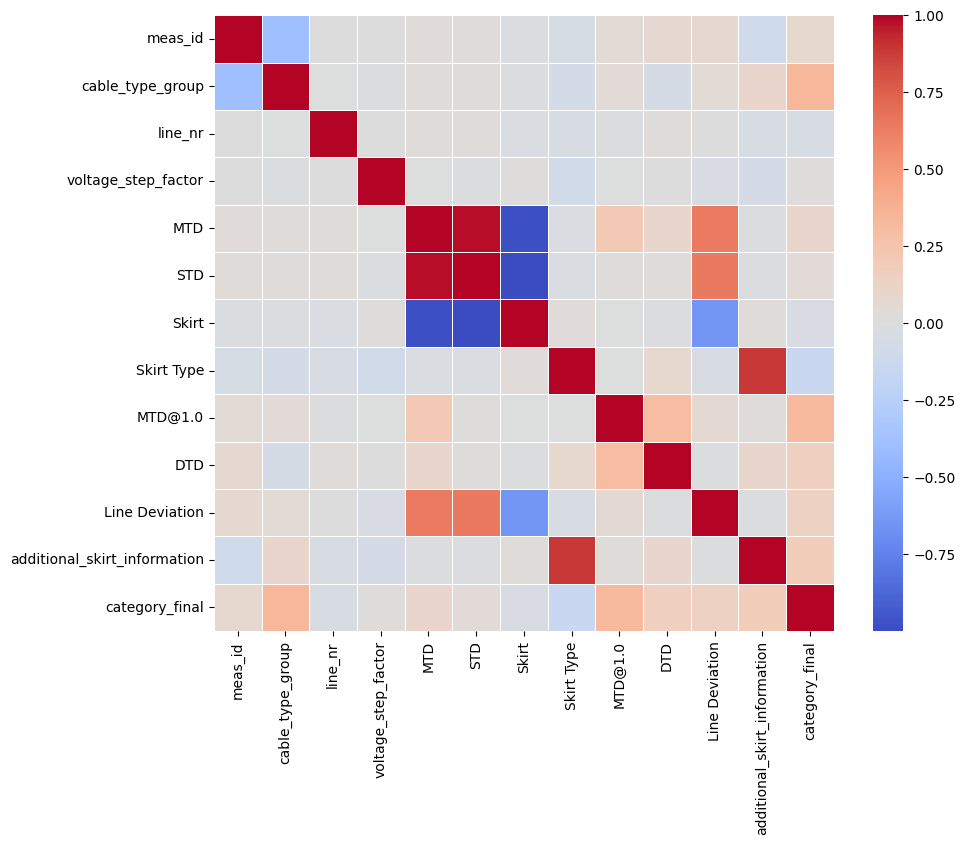

In [12]:
# drop columns with no relevance except meas_id. It is a unique identifier for each row
data_for_analysis = data.drop(['cable_id', 'date', 'time', 'step_id', 'category_mtd', 'category_dtd', 'category_std', 'category_line_deviation'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [13]:
data_for_analysis

,meas_id,cable_type_group,line_nr,voltage_step_factor,MTD,STD,Skirt,Skirt Type,MTD@1.0,DTD,Line Deviation,additional_skirt_information,category_final
0,132,1,1,0.5,3.950,0.050,0.02571,2,4.583,2.650,2.21,7,3
1,132,1,1,1.0,4.583,0.037,0.01429,2,4.583,2.650,2.40,7,3
2,132,1,1,1.5,6.600,0.082,0.02286,2,4.583,2.650,2.13,7,3
3,132,1,1,2.0,9.750,0.050,0.00857,2,4.583,2.650,2.02,7,3
4,132,1,2,0.5,4.333,0.047,0.02286,2,5.117,2.550,2.01,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,212,0,3,0.8,0.021,0.029,-0.00157,0,0.164,0.148,1.39,0,1
2778,212,0,3,1.0,0.164,0.196,-0.04118,0,0.164,0.148,1.39,0,1
2779,212,0,3,1.3,0.083,0.108,-0.00808,0,0.164,0.148,2.52,0,3
2780,212,0,3,1.5,0.154,0.130,0.04264,2,0.164,0.148,5.31,4,4


In [14]:
# Drop rows where 'MTD' > 4000 and 'STD' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['MTD'] > 4000) & (data_for_analysis['STD'] > 5000))]

In [15]:
# Column to group by but not use for training
group_column = 'meas_id'
groups = data_for_analysis['meas_id']

In [16]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column, group_column],axis=1)

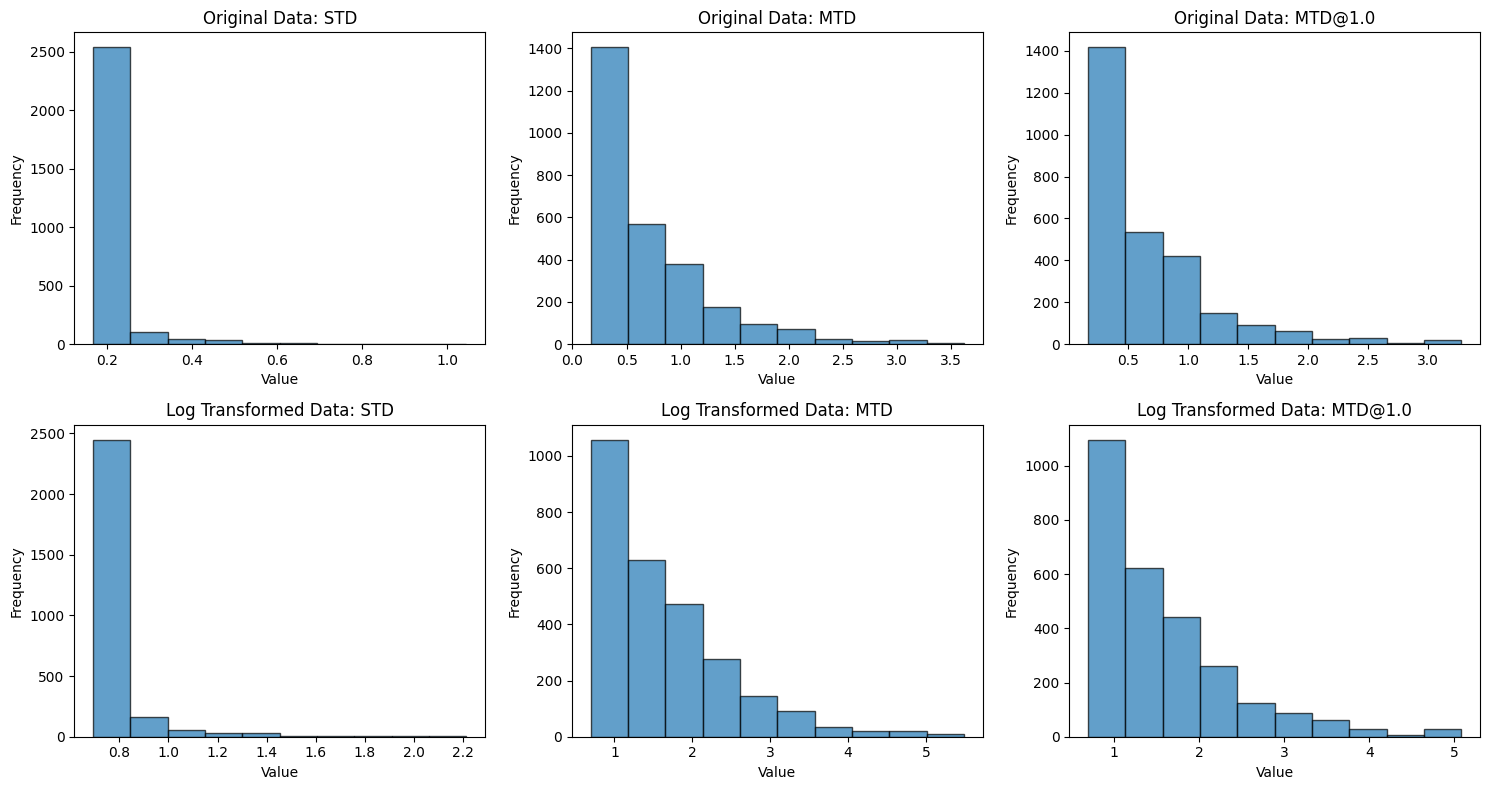

In [17]:
# Define numerical features
numerical_features = ['STD', 'MTD', 'MTD@1.0']

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
# Standard deviation before scaling
x.std()

cable_type_group                 0.808883
line_nr                          0.816547
voltage_step_factor              0.506494
MTD                             16.791678
STD                              0.511824
Skirt                            0.180870
Skirt Type                       0.954761
MTD@1.0                         15.674216
DTD                              5.560254
Line Deviation                   6.398569
additional_skirt_information     2.404509
dtype: float64

In [19]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [20]:
# standard deviation after scaling
x_standardized.std()

cable_type_group                1.000181
line_nr                         1.000181
voltage_step_factor             1.000181
MTD                             1.000181
STD                             1.000181
Skirt                           1.000181
Skirt Type                      1.000181
MTD@1.0                         1.000181
DTD                             1.000181
Line Deviation                  1.000181
additional_skirt_information    1.000181
dtype: float64

In [21]:
x_standardized.columns

Index(['cable_type_group', 'line_nr', 'voltage_step_factor', 'MTD', 'STD',
       'Skirt', 'Skirt Type', 'MTD@1.0', 'DTD', 'Line Deviation',
       'additional_skirt_information'],
      dtype='object')

In [22]:
# Initialize GroupShuffleSplit
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Split the data
train_idx, test_idx = next(gss.split(x_standardized, y, groups=groups))

# Create train and test sets
X_train, X_test = x_standardized.iloc[train_idx], x_standardized.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


### Supervised Modelling

#### XGBoost

In [23]:
def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9476
F1 Score: 0.9478


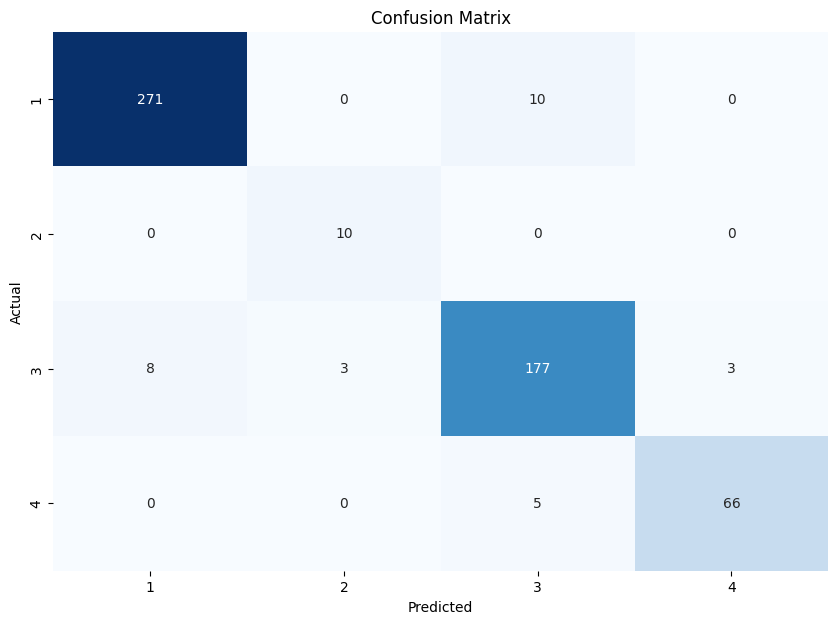

<Figure size 1000x600 with 0 Axes>

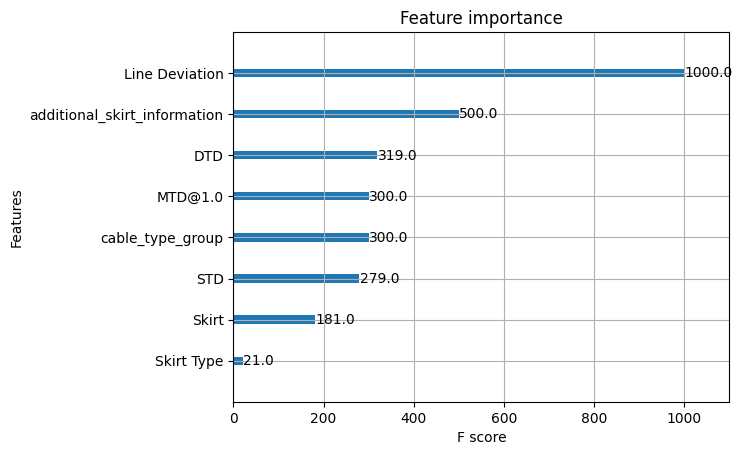

In [24]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


In [25]:

def objective_xgb(trial, X_train, y_train, cv=3):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)
    max_depth = trial.suggest_int('max_depth', 3, 6, step=1)
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    subsample = trial.suggest_float('subsample', 0.8, 1.0, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    gamma = trial.suggest_float('gamma', 0, 5, step=1)

    # Initialize model
    xgb = XGBClassifier(
        objective='multi:softmax',
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        random_state=20,
        eval_metric='mlogloss',
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1

In [26]:
def xgboost_classifier_with_optuna(X, y, n_trials=30, cv=3):
    """Runs Optuna to optimize hyperparameters and train the best XGBoost model."""
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_xgb(trial, X_train, y_train, cv=cv), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = XGBClassifier(**best_params, objective='multi:softmax', random_state=20, eval_metric='mlogloss', n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=np.unique(y_test), 
                yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-02-19 17:00:06,635] A new study created in memory with name: no-name-2dd441c4-4fe5-4be0-b929-56ff04257836
[I 2025-02-19 17:00:09,103] Trial 0 finished with value: 0.9785293496926467 and parameters: {'learning_rate': 0.13, 'max_depth': 5, 'n_estimators': 170, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 2.0}. Best is trial 0 with value: 0.9785293496926467.
[I 2025-02-19 17:00:09,575] Trial 1 finished with value: 0.9791112350034497 and parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 160, 'subsample': 1.0, 'colsample_bytree': 0.8, 'gamma': 2.0}. Best is trial 1 with value: 0.9791112350034497.
[I 2025-02-19 17:00:10,107] Trial 2 finished with value: 0.9735668919564384 and parameters: {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 160, 'subsample': 0.8, 'colsample_bytree': 0.6, 'gamma': 3.0}. Best is trial 1 with value: 0.9791112350034497.
[I 2025-02-19 17:00:10,600] Trial 3 finished with value: 0.9772227303382462 and parameters: {'learning_rate': 

Best Parameters: {'learning_rate': 0.19, 'max_depth': 6, 'n_estimators': 60, 'subsample': 0.8, 'colsample_bytree': 0.7, 'gamma': 0.0}
Test Accuracy: 0.9964
Test F1 Score: 0.9964


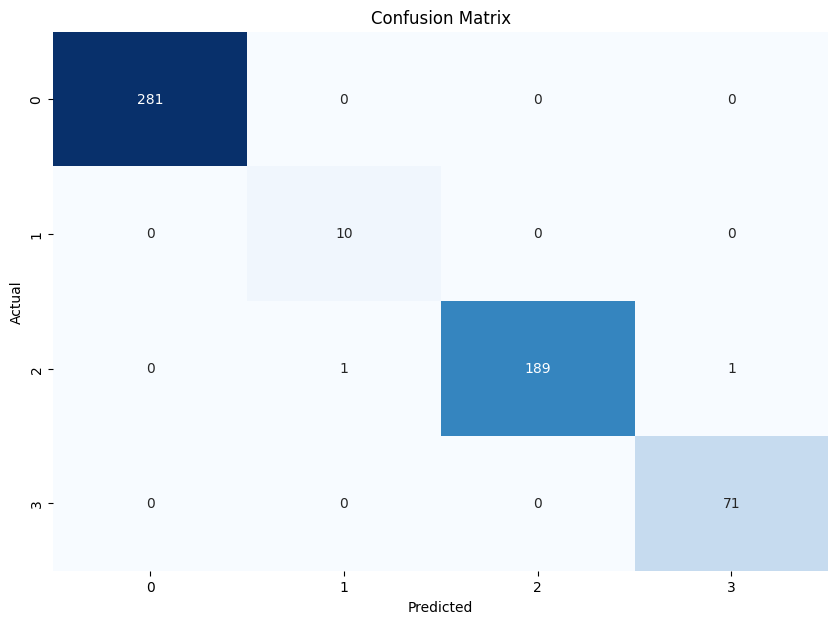

Optimal Parameters: {'learning_rate': 0.19, 'max_depth': 6, 'n_estimators': 60, 'subsample': 0.8, 'colsample_bytree': 0.7, 'gamma': 0.0}
Test Accuracy: 0.9963833634719711
F1 Score: 0.9964232239953188


In [27]:
best_model_xgb, best_params, accuracy, f1, cm = xgboost_classifier_with_optuna(x_standardized, y_adjusted, n_trials=30, cv=3)

# Results
print(f"Optimal Parameters: {best_params}")
print(f"Test Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


#### Random Forest

In [28]:
def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9910
F1 Score: 0.9910


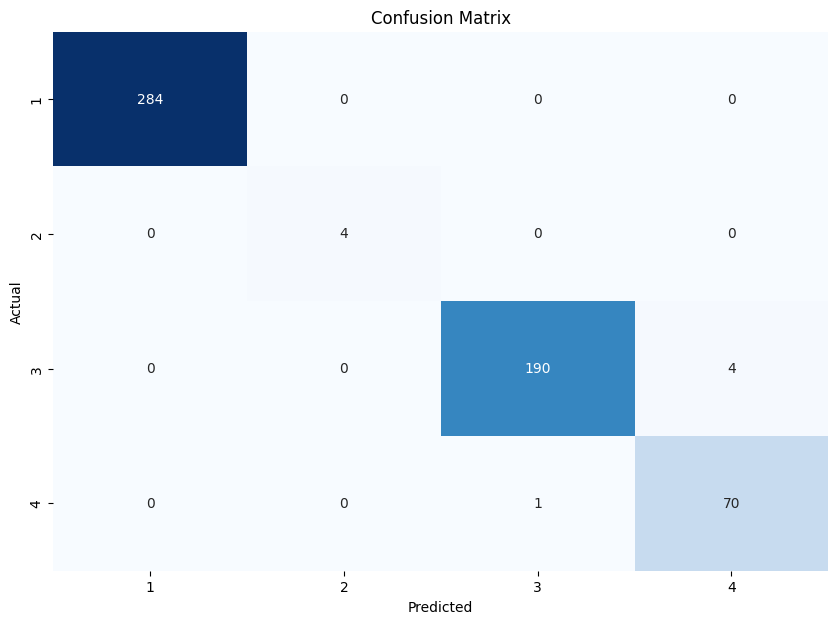

In [29]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


                         Feature  Importance
10  additional_skirt_information    0.265825
9                 Line Deviation    0.192249
8                            DTD    0.139888
0               cable_type_group    0.116731
7                        MTD@1.0    0.073607
4                            STD    0.073300
3                            MTD    0.054725
5                          Skirt    0.054070
6                     Skirt Type    0.021141
2            voltage_step_factor    0.004906
1                        line_nr    0.003559


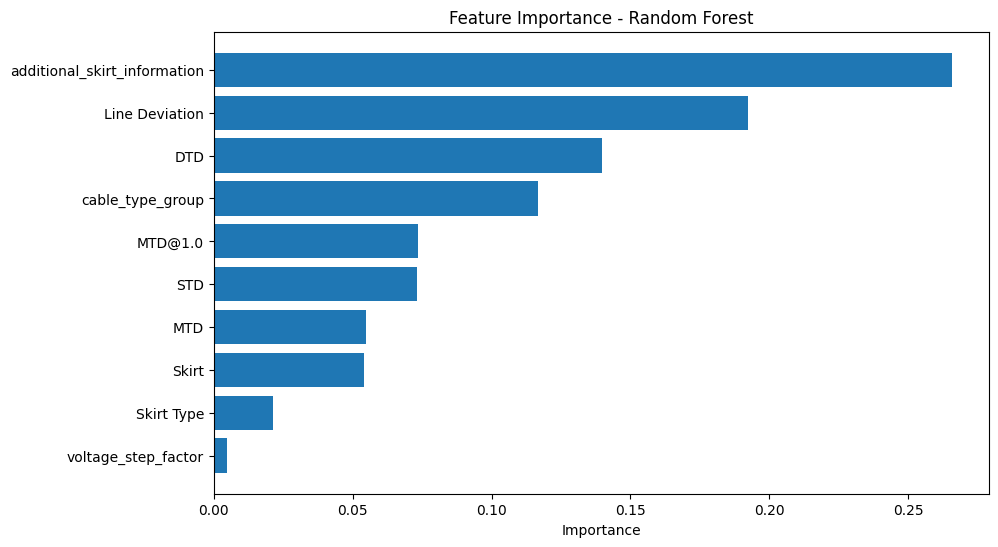

In [30]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [31]:
def objective_rf(trial, X_train, y_train):
    """Objective function for Optuna to optimize RandomForest hyperparameters."""
    
    # Define search space
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 20, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4, step=1)

    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=20,
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1  # Optuna tries to maximize this

In [32]:
def random_forest_classifier_with_optuna(X, y, n_trials=30):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_rf(trial, X_train, y_train), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = RandomForestClassifier(**best_params, random_state=20, n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-02-19 17:00:14,763] A new study created in memory with name: no-name-244754da-d020-4781-86e4-228a87de2423
[I 2025-02-19 17:00:15,173] Trial 0 finished with value: 0.9840040296955923 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9840040296955923.
[I 2025-02-19 17:00:15,386] Trial 1 finished with value: 0.9816578023503985 and parameters: {'n_estimators': 70, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9840040296955923.
[I 2025-02-19 17:00:15,769] Trial 2 finished with value: 0.9867020322589231 and parameters: {'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.9867020322589231.
[I 2025-02-19 17:00:16,003] Trial 3 finished with value: 0.9853331135146588 and parameters: {'n_estimators': 120, 'criterion': 'entro

Best Parameters: {'n_estimators': 110, 'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1}
Accuracy: 0.9928
F1 Score: 0.9928


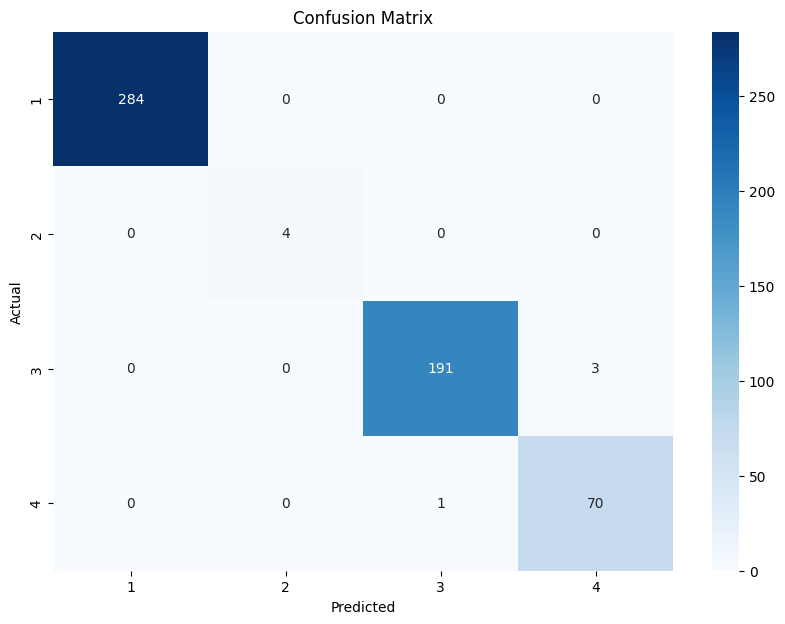

In [33]:
# Perform hyperparameter tuning and retrieve the best parameters
best_rf_model, best_rf_params, accuracy, f1, cm = random_forest_classifier_with_optuna(x_standardized, y)

#### KNN 

In [34]:
def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [35]:
def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.9078
F1 Score: 0.9029


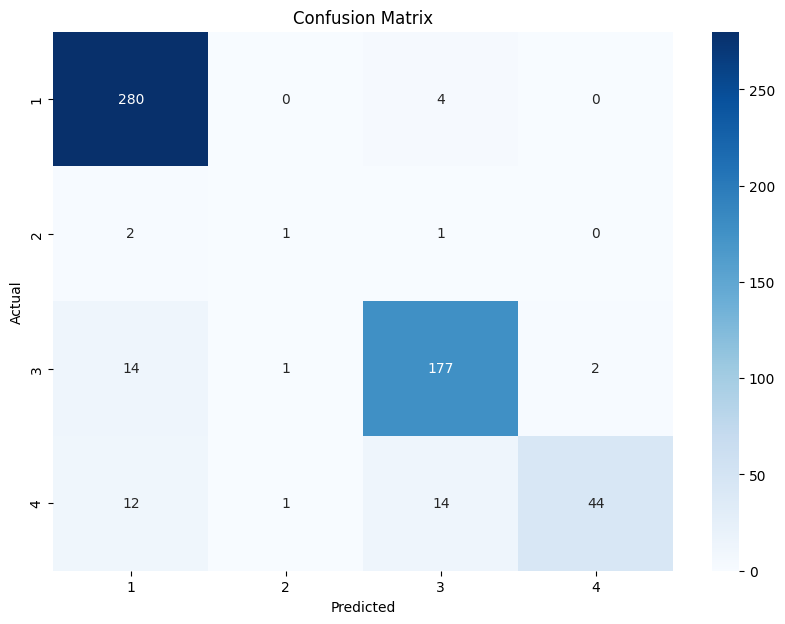

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'p': 1}
Best Score: 0.9022152450723879


In [36]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)
knn_best_params = knn_hyperparameter_tuning(x_standardized, y)

#### Progressive Validation

In [37]:
def progressive_validation(model, X, y, groups):
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []
    
    # Reset index to avoid mismatches
    X, y, groups = X.reset_index(drop=True), y.reset_index(drop=True), groups.reset_index(drop=True)
    sorted_indices = np.argsort(groups.to_numpy()) 
    X, y, groups = X.iloc[sorted_indices], y.iloc[sorted_indices], groups.iloc[sorted_indices]

    gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    for split in splits:
        subset_idx = train_idx[:int(len(train_idx) * split)]  
        X_train, y_train = X.iloc[subset_idx], y.iloc[subset_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results

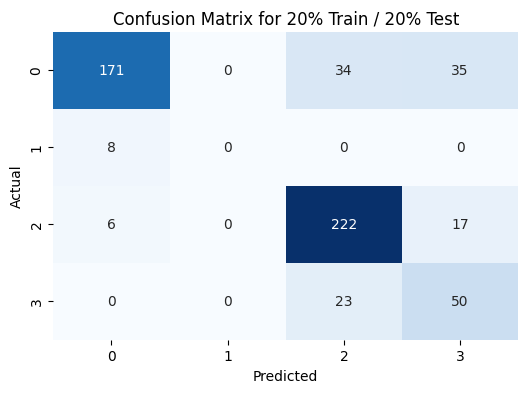

Results for 20% train / 20% test:
Accuracy: 0.7827
F1 Score: 0.7817
----------------------------------------


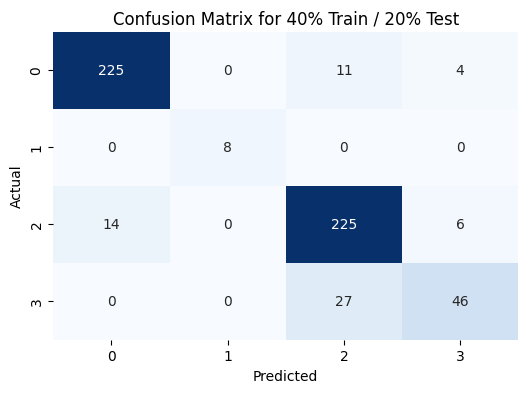

Results for 40% train / 20% test:
Accuracy: 0.8905
F1 Score: 0.8879
----------------------------------------


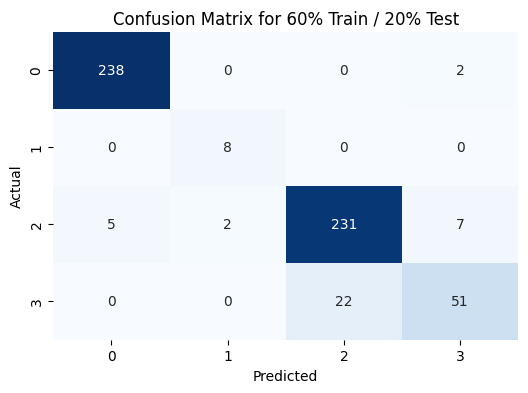

Results for 60% train / 20% test:
Accuracy: 0.9329
F1 Score: 0.9309
----------------------------------------


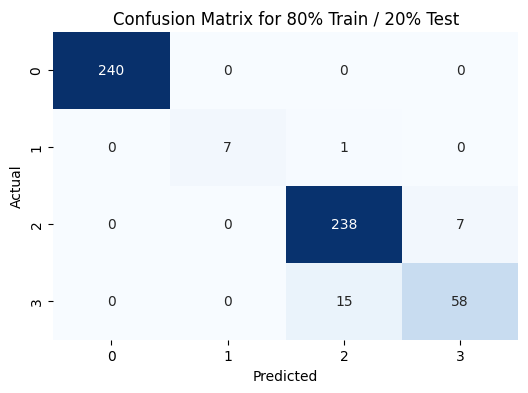

Results for 80% train / 20% test:
Accuracy: 0.9594
F1 Score: 0.9585
----------------------------------------
XGBoost Results:
{'split': '20% train / 20% test', 'accuracy': 0.7826855123674912, 'f1_score': np.float64(0.7816945535800703), 'confusion_matrix': array([[171,   0,  34,  35],
       [  8,   0,   0,   0],
       [  6,   0, 222,  17],
       [  0,   0,  23,  50]])}
{'split': '40% train / 20% test', 'accuracy': 0.8904593639575972, 'f1_score': np.float64(0.8879139631806479), 'confusion_matrix': array([[225,   0,  11,   4],
       [  0,   8,   0,   0],
       [ 14,   0, 225,   6],
       [  0,   0,  27,  46]])}
{'split': '60% train / 20% test', 'accuracy': 0.9328621908127208, 'f1_score': np.float64(0.9309310411202596), 'confusion_matrix': array([[238,   0,   0,   2],
       [  0,   8,   0,   0],
       [  5,   2, 231,   7],
       [  0,   0,  22,  51]])}
{'split': '80% train / 20% test', 'accuracy': 0.9593639575971732, 'f1_score': np.float64(0.9585448769203281), 'confusion_matrix': 

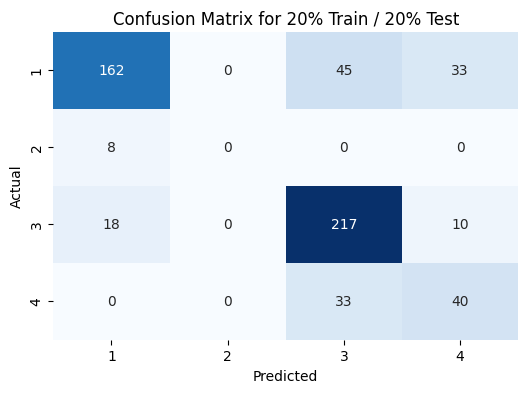

Results for 20% train / 20% test:
Accuracy: 0.7403
F1 Score: 0.7350
----------------------------------------


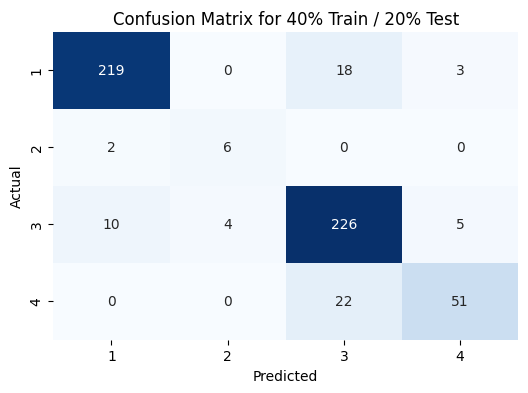

Results for 40% train / 20% test:
Accuracy: 0.8869
F1 Score: 0.8863
----------------------------------------


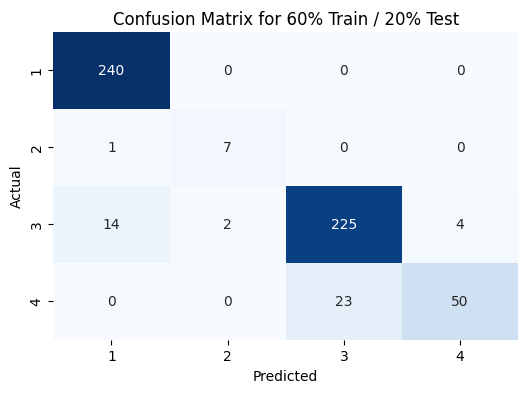

Results for 60% train / 20% test:
Accuracy: 0.9223
F1 Score: 0.9195
----------------------------------------


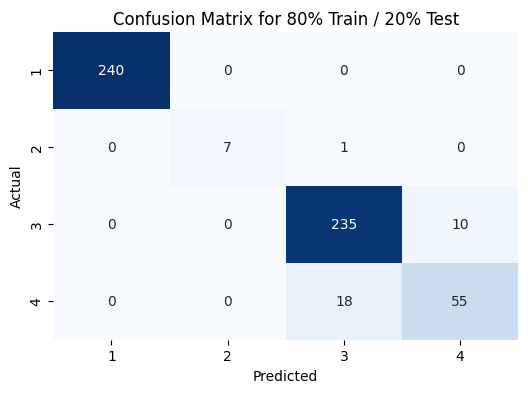

Results for 80% train / 20% test:
Accuracy: 0.9488
F1 Score: 0.9477
----------------------------------------
Random Forest Results:
{'split': '20% train / 20% test', 'accuracy': 0.7402826855123675, 'f1_score': np.float64(0.7350274696713058), 'confusion_matrix': array([[162,   0,  45,  33],
       [  8,   0,   0,   0],
       [ 18,   0, 217,  10],
       [  0,   0,  33,  40]])}
{'split': '40% train / 20% test', 'accuracy': 0.8869257950530035, 'f1_score': np.float64(0.8862888098680983), 'confusion_matrix': array([[219,   0,  18,   3],
       [  2,   6,   0,   0],
       [ 10,   4, 226,   5],
       [  0,   0,  22,  51]])}
{'split': '60% train / 20% test', 'accuracy': 0.9222614840989399, 'f1_score': np.float64(0.9194817219523364), 'confusion_matrix': array([[240,   0,   0,   0],
       [  1,   7,   0,   0],
       [ 14,   2, 225,   4],
       [  0,   0,  23,  50]])}
{'split': '80% train / 20% test', 'accuracy': 0.9487632508833922, 'f1_score': np.float64(0.9477325009008134), 'confusion_mat

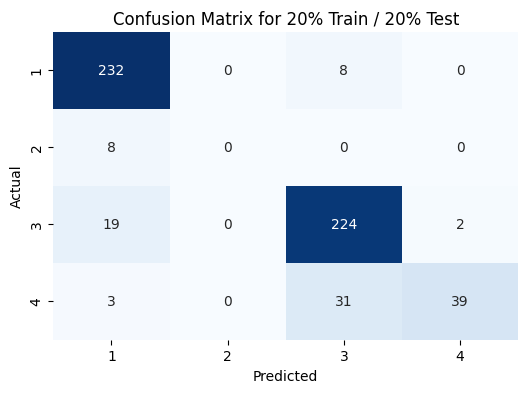

Results for 20% train / 20% test:
Accuracy: 0.8746
F1 Score: 0.8619
----------------------------------------


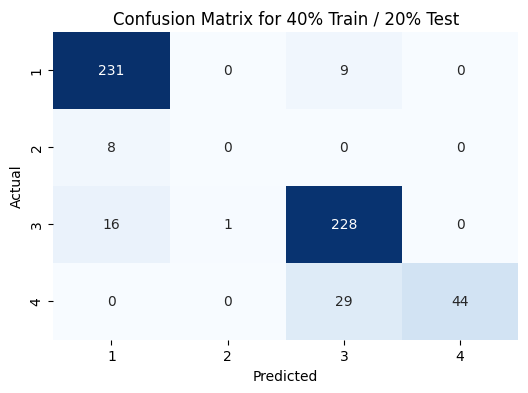

Results for 40% train / 20% test:
Accuracy: 0.8887
F1 Score: 0.8790
----------------------------------------


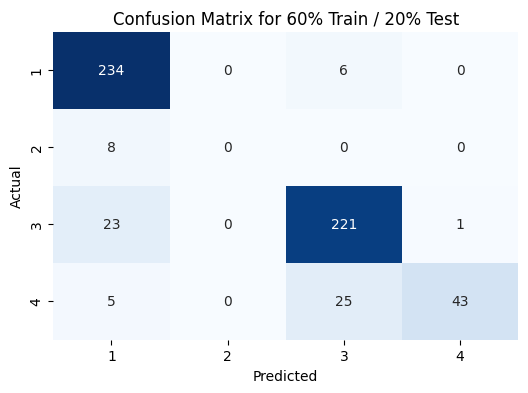

Results for 60% train / 20% test:
Accuracy: 0.8799
F1 Score: 0.8689
----------------------------------------


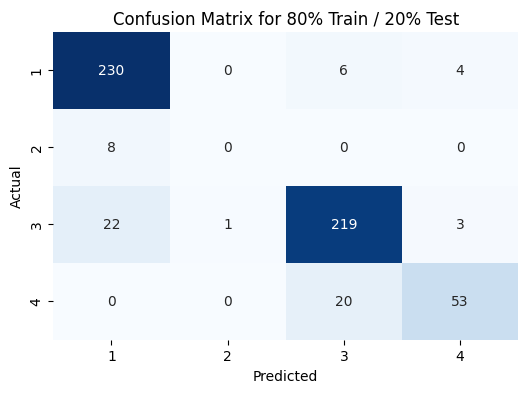

Results for 80% train / 20% test:
Accuracy: 0.8869
F1 Score: 0.8798
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.8745583038869258,
  'f1_score': np.float64(0.8619134803352403),
  'confusion_matrix': array([[232,   0,   8,   0],
         [  8,   0,   0,   0],
         [ 19,   0, 224,   2],
         [  3,   0,  31,  39]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.8886925795053003,
  'f1_score': np.float64(0.8790390810817743),
  'confusion_matrix': array([[231,   0,   9,   0],
         [  8,   0,   0,   0],
         [ 16,   1, 228,   0],
         [  0,   0,  29,  44]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.8798586572438163,
  'f1_score': np.float64(0.8688705613417468),
  'confusion_matrix': array([[234,   0,   6,   0],
         [  8,   0,   0,   0],
         [ 23,   0, 221,   1],
         [  5,   0,  25,  43]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.8869257950530035,
  'f1_score': np.float64(0.8798241186003879),
  'confusion_matrix': array([[230,   0,   6,   4],
         [  8,   0,   0,   0],
         [ 22,   

In [ ]:
# Run progressive validation
print("XGBoost Results:")
progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)

# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
print("Random Forest Results:")
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)

# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)

#### Run the model without Additional Skirt Info

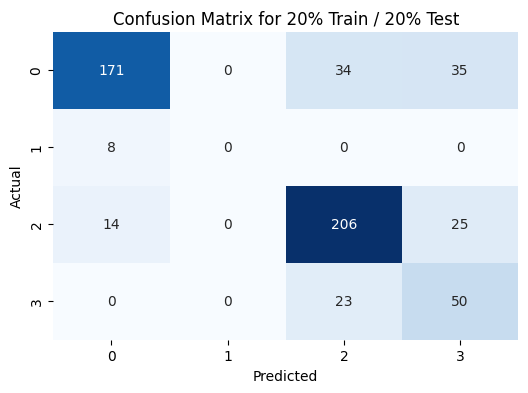

Results for 20% train / 20% test:
Accuracy: 0.7544
F1 Score: 0.7565
----------------------------------------


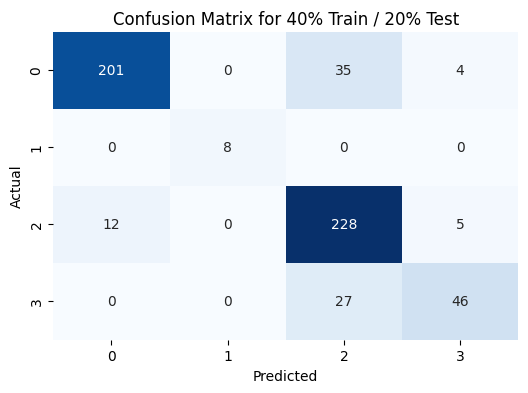

Results for 40% train / 20% test:
Accuracy: 0.8534
F1 Score: 0.8521
----------------------------------------


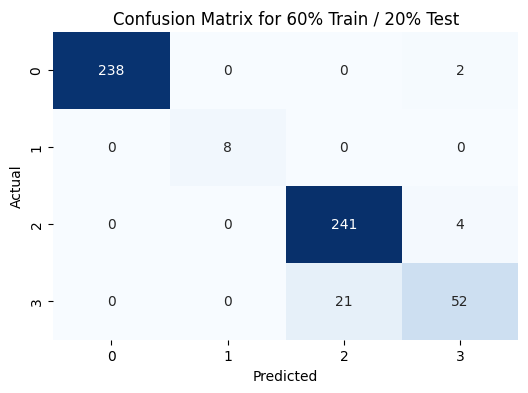

Results for 60% train / 20% test:
Accuracy: 0.9523
F1 Score: 0.9503
----------------------------------------


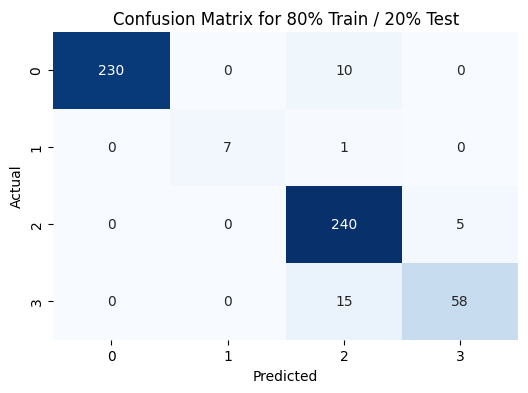

Results for 80% train / 20% test:
Accuracy: 0.9452
F1 Score: 0.9448
----------------------------------------
XGBoost Results:
{'split': '20% train / 20% test', 'accuracy': 0.7544169611307421, 'f1_score': np.float64(0.7564535312859999), 'confusion_matrix': array([[171,   0,  34,  35],
       [  8,   0,   0,   0],
       [ 14,   0, 206,  25],
       [  0,   0,  23,  50]])}
{'split': '40% train / 20% test', 'accuracy': 0.8533568904593639, 'f1_score': np.float64(0.8520694564609067), 'confusion_matrix': array([[201,   0,  35,   4],
       [  0,   8,   0,   0],
       [ 12,   0, 228,   5],
       [  0,   0,  27,  46]])}
{'split': '60% train / 20% test', 'accuracy': 0.9522968197879859, 'f1_score': np.float64(0.9502988454465819), 'confusion_matrix': array([[238,   0,   0,   2],
       [  0,   8,   0,   0],
       [  0,   0, 241,   4],
       [  0,   0,  21,  52]])}
{'split': '80% train / 20% test', 'accuracy': 0.9452296819787986, 'f1_score': np.float64(0.9448091446495868), 'confusion_matrix': 

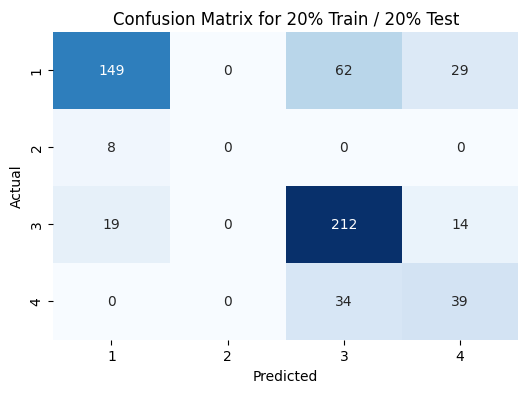

Results for 20% train / 20% test:
Accuracy: 0.7067
F1 Score: 0.7005
----------------------------------------


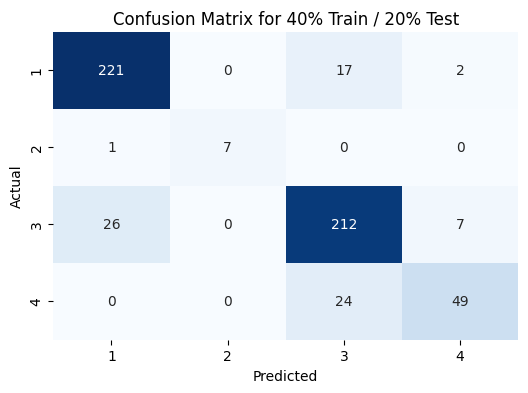

Results for 40% train / 20% test:
Accuracy: 0.8640
F1 Score: 0.8623
----------------------------------------


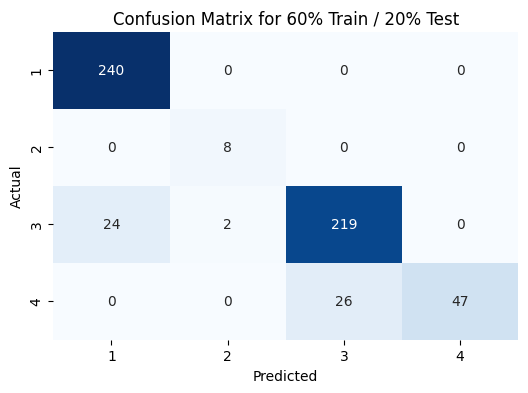

Results for 60% train / 20% test:
Accuracy: 0.9081
F1 Score: 0.9044
----------------------------------------


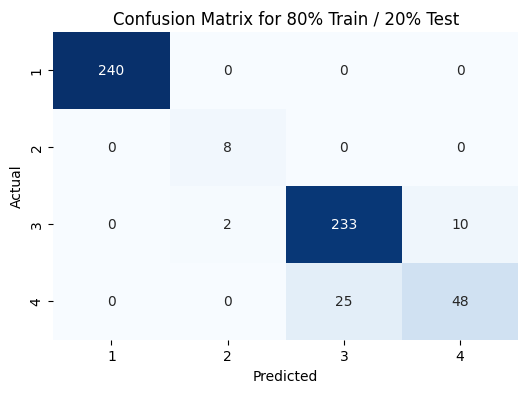

Results for 80% train / 20% test:
Accuracy: 0.9346
F1 Score: 0.9321
----------------------------------------
Random Forest Results:
{'split': '20% train / 20% test', 'accuracy': 0.7067137809187279, 'f1_score': np.float64(0.7005418057594832), 'confusion_matrix': array([[149,   0,  62,  29],
       [  8,   0,   0,   0],
       [ 19,   0, 212,  14],
       [  0,   0,  34,  39]])}
{'split': '40% train / 20% test', 'accuracy': 0.8639575971731449, 'f1_score': np.float64(0.8622769971376951), 'confusion_matrix': array([[221,   0,  17,   2],
       [  1,   7,   0,   0],
       [ 26,   0, 212,   7],
       [  0,   0,  24,  49]])}
{'split': '60% train / 20% test', 'accuracy': 0.9081272084805654, 'f1_score': np.float64(0.9043566661057827), 'confusion_matrix': array([[240,   0,   0,   0],
       [  0,   8,   0,   0],
       [ 24,   2, 219,   0],
       [  0,   0,  26,  47]])}
{'split': '80% train / 20% test', 'accuracy': 0.9346289752650176, 'f1_score': np.float64(0.9321297270847025), 'confusion_mat

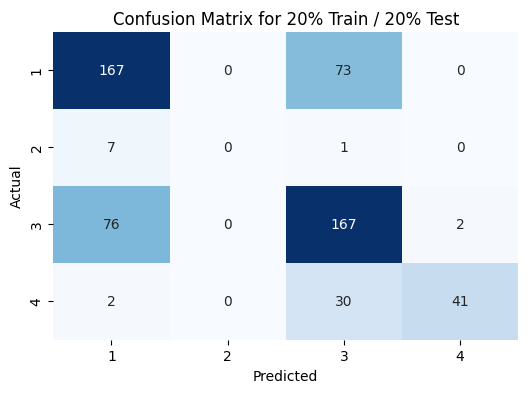

Results for 20% train / 20% test:
Accuracy: 0.6625
F1 Score: 0.6592
----------------------------------------


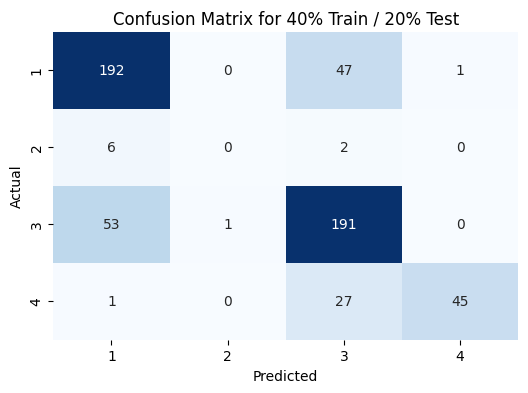

Results for 40% train / 20% test:
Accuracy: 0.7562
F1 Score: 0.7514
----------------------------------------


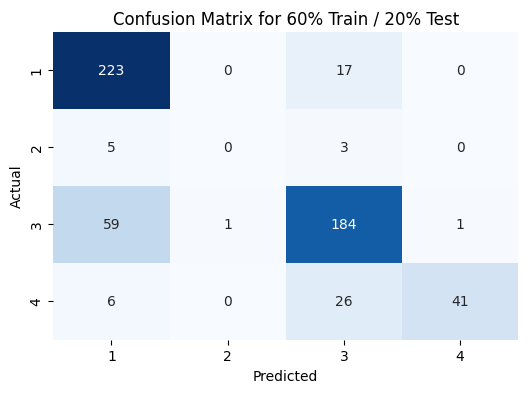

Results for 60% train / 20% test:
Accuracy: 0.7915
F1 Score: 0.7821
----------------------------------------


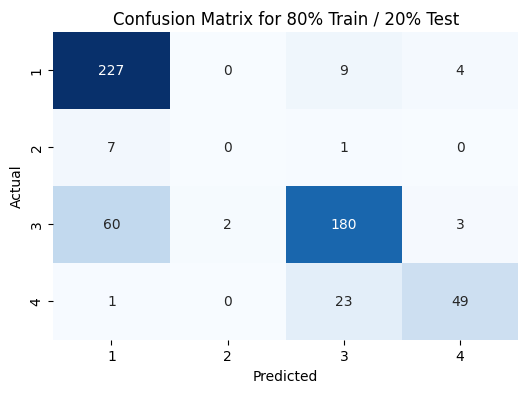

Results for 80% train / 20% test:
Accuracy: 0.8057
F1 Score: 0.7981
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.6625441696113075,
  'f1_score': np.float64(0.659214750639548),
  'confusion_matrix': array([[167,   0,  73,   0],
         [  7,   0,   1,   0],
         [ 76,   0, 167,   2],
         [  2,   0,  30,  41]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.7561837455830389,
  'f1_score': np.float64(0.7514489857850621),
  'confusion_matrix': array([[192,   0,  47,   1],
         [  6,   0,   2,   0],
         [ 53,   1, 191,   0],
         [  1,   0,  27,  45]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.7915194346289752,
  'f1_score': np.float64(0.7821346575553005),
  'confusion_matrix': array([[223,   0,  17,   0],
         [  5,   0,   3,   0],
         [ 59,   1, 184,   1],
         [  6,   0,  26,  41]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.8056537102473498,
  'f1_score': np.float64(0.7980518285458096),
  'confusion_matrix': array([[227,   0,   9,   4],
         [  7,   0,   1,   0],
         [ 60,   2

In [41]:
x_standardized = x_standardized.drop(['additional_skirt_information'],axis=1)

progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)
print("XGBoost Results:")
# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)
print("Random Forest Results:")
# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)